<a href="https://colab.research.google.com/github/Ishini01/garment_defect_system/blob/main/BrokenStichesEfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import the Google Drive module from Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

search_roots = [
    "/content/drive/MyDrive/Dataset_GarmentDefectDetection",
    "/content/drive/MyDrive/Garment_Defect_Dataset"
]

keywords = ["broken", "normal", "stitch"]

for root_path in search_roots:

    print("\n" + "="*70)
    print("SEARCHING:", root_path)
    print("="*70)

    if not os.path.exists(root_path):
        print("❌ Folder does not exist")
        continue

    for current_root, dirs, files in os.walk(root_path):

        # Print folders that look relevant
        relevant_dirs = [
            d for d in dirs
            if any(keyword in d.lower() for keyword in keywords)
        ]

        for d in relevant_dirs:
            folder_path = os.path.join(current_root, d)

            # Count image files
            image_count = sum(
                1 for f in os.listdir(folder_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
                )
            )

            print(f"📁 {folder_path}")
            print(f"   🖼️ Images: {image_count}")


SEARCHING: /content/drive/MyDrive/Dataset_GarmentDefectDetection
📁 /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches
   🖼️ Images: 0
📁 /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/broken stitches
   🖼️ Images: 1017
📁 /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/Normal Stitches
   🖼️ Images: 1395
📁 /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train/broken stitches
   🖼️ Images: 711
📁 /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train/Normal Stitches
   🖼️ Images: 976
📁 /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/validation/broken stitches
   🖼️ Images: 152
📁 /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/validation/Normal Stitches
   🖼️ Images: 209
📁 /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_

In [ ]:
import os
import shutil
import random

# ============================================================
# 1. SOURCE DATASET PATH
# ============================================================

source_root = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches"

broken_source = os.path.join(source_root, "broken stitches")
normal_source = os.path.join(source_root, "Normal Stitches")


# ============================================================
# 2. DESTINATION PATH
# ============================================================

split_root = os.path.join(source_root, "split_dataset")


# ============================================================
# 3. CHECK SOURCE FOLDERS
# ============================================================

print("=" * 70)
print("CHECKING SOURCE DATASET")
print("=" * 70)

print("\nBroken stitches path:")
print(broken_source)
print("Exists:", os.path.exists(broken_source))

print("\nNormal Stitches path:")
print(normal_source)
print("Exists:", os.path.exists(normal_source))


if not os.path.exists(broken_source):
    raise FileNotFoundError("❌ Broken stitches folder not found!")

if not os.path.exists(normal_source):
    raise FileNotFoundError("❌ Normal Stitches folder not found!")


# ============================================================
# 4. GET IMAGE FILES
# ============================================================

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


broken_images = [
    f for f in os.listdir(broken_source)
    if f.lower().endswith(image_extensions)
]

normal_images = [
    f for f in os.listdir(normal_source)
    if f.lower().endswith(image_extensions)
]


print("\n" + "=" * 70)
print("SOURCE IMAGE COUNTS")
print("=" * 70)

print(f"Broken stitches : {len(broken_images)}")
print(f"Normal Stitches : {len(normal_images)}")
print(f"Total           : {len(broken_images) + len(normal_images)}")


# ============================================================
# 5. FIXED RANDOM SEED
# ============================================================

random.seed(42)


# ============================================================
# 6. FUNCTION TO CREATE SPLIT
# ============================================================

def split_images(images):

    images = images.copy()
    random.shuffle(images)

    total = len(images)

    train_count = int(total * 0.70)
    validation_count = int(total * 0.15)

    train_images = images[:train_count]

    validation_images = images[
        train_count:train_count + validation_count
    ]

    test_images = images[
        train_count + validation_count:
    ]

    return train_images, validation_images, test_images


# ============================================================
# 7. CREATE SPLITS
# ============================================================

broken_train, broken_validation, broken_test = split_images(
    broken_images
)

normal_train, normal_validation, normal_test = split_images(
    normal_images
)


# ============================================================
# 8. CREATE DESTINATION FOLDERS
# ============================================================

splits = {
    "train": {
        "broken stitches": broken_train,
        "Normal Stitches": normal_train
    },

    "validation": {
        "broken stitches": broken_validation,
        "Normal Stitches": normal_validation
    },

    "test": {
        "broken stitches": broken_test,
        "Normal Stitches": normal_test
    }
}


for split_name, classes in splits.items():

    for class_name in classes:

        destination = os.path.join(
            split_root,
            split_name,
            class_name
        )

        os.makedirs(destination, exist_ok=True)


# ============================================================
# 9. COPY IMAGES
# ============================================================

print("\n" + "=" * 70)
print("COPYING IMAGES")
print("=" * 70)

source_paths = {
    "broken stitches": broken_source,
    "Normal Stitches": normal_source
}

for split_name, classes in splits.items():

    for class_name, image_list in classes.items():

        source_folder = source_paths[class_name]

        destination_folder = os.path.join(
            split_root,
            split_name,
            class_name
        )

        for image_name in image_list:

            source_file = os.path.join(
                source_folder,
                image_name
            )

            destination_file = os.path.join(
                destination_folder,
                image_name
            )

            shutil.copy2(
                source_file,
                destination_file
            )

        print(
            f"✅ {split_name:12} | "
            f"{class_name:16} | "
            f"{len(image_list)} images"
        )


# ============================================================
# 10. FINAL VERIFICATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET SPLIT")
print("=" * 70)

grand_total = 0

for split_name in ["train", "validation", "test"]:

    split_total = 0

    print(f"\n📁 {split_name.upper()}")

    for class_name in ["broken stitches", "Normal Stitches"]:

        folder = os.path.join(
            split_root,
            split_name,
            class_name
        )

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(image_extensions)
        ])

        print(f"   {class_name}: {count}")

        split_total += count

    print(f"   ➜ Total: {split_total}")

    grand_total += split_total


print("\n" + "=" * 70)
print(f"TOTAL IMAGES IN ALL SPLITS: {grand_total}")
print("=" * 70)

if grand_total == 2412:
    print("🎉 SUCCESS! All 2,412 images were split successfully.")
else:
    print("⚠️ WARNING: Total is not 2,412. Please check the output.")

CHECKING SOURCE DATASET

Broken stitches path:
/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/broken stitches
Exists: True

Normal Stitches path:
/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/Normal Stitches
Exists: True

SOURCE IMAGE COUNTS
Broken stitches : 1017
Normal Stitches : 1395
Total           : 2412

COPYING IMAGES


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

print("\nGPU Available:", tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("✅ GPU is available. Training can use GPU.")
else:
    print("⚠️ GPU is not available. Training will use CPU.")

TensorFlow version: 2.20.0

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU is available. Training can use GPU.


In [ ]:
BASE_DIR = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches"

TRAIN_DIR = f"{BASE_DIR}/split_dataset/train"
VAL_DIR   = f"{BASE_DIR}/split_dataset/validation"
TEST_DIR  = f"{BASE_DIR}/split_dataset/test"

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train
Validation: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/validation
Test: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/test


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

tf.random.set_seed(SEED)


# ============================================================
# IMAGE & TRAINING SETTINGS
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


# ============================================================
# TRAINING DATA AUGMENTATION
# ============================================================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)


# ============================================================
# VALIDATION & TEST
# NO AUGMENTATION
# ============================================================

val_test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)


# ============================================================
# TRAIN GENERATOR
# ============================================================

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)


# ============================================================
# VALIDATION GENERATOR
# ============================================================

validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


# ============================================================
# TEST GENERATOR
# ============================================================

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


# ============================================================
# DISPLAY INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("DATA GENERATOR INFORMATION")
print("=" * 60)

print("Class mapping:", train_generator.class_indices)

print("Training images:", train_generator.samples)
print("Validation images:", validation_generator.samples)
print("Test images:", test_generator.samples)

print("=" * 60)

Found 1687 images belonging to 2 classes.
Found 361 images belonging to 2 classes.
Found 364 images belonging to 2 classes.

DATA GENERATOR INFORMATION
Class mapping: {'Normal Stitches': 0, 'broken stitches': 1}
Training images: 1687
Validation images: 361
Test images: 364


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train"

VAL_DIR = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/validation"

TEST_DIR = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/test"

In [ ]:
print("Train exists:", os.path.exists(TRAIN_DIR))
print("Validation exists:", os.path.exists(VAL_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Validation exists: True
Test exists: True


In [ ]:
print("Training folders:")
print(os.listdir(TRAIN_DIR))

print("\nValidation folders:")
print(os.listdir(VAL_DIR))

print("\nTest folders:")
print(os.listdir(TEST_DIR))

Training folders:
['broken stitches', 'Normal Stitches']

Validation folders:
['broken stitches', 'Normal Stitches']

Test folders:
['broken stitches', 'Normal Stitches']


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

Found 1687 files belonging to 2 classes.


In [ ]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 361 files belonging to 2 classes.


In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 364 files belonging to 2 classes.


In [ ]:
for images, labels in train_dataset.take(1):

    print("Image shape:", images.shape)
    print("Image dtype:", images.dtype)

    print("Label shape:", labels.shape)
    print("Labels:", labels.numpy()[:20])

    print("Minimum pixel value:",
          tf.reduce_min(images).numpy())

    print("Maximum pixel value:",
          tf.reduce_max(images).numpy())

    print("Contains NaN:",
          tf.reduce_any(tf.math.is_nan(images)).numpy())

    print("Contains Inf:",
          tf.reduce_any(tf.math.is_inf(images)).numpy())

Image shape: (32, 224, 224, 3)
Image dtype: <dtype: 'float32'>
Label shape: (32,)
Labels: [1 1 0 0 1 0 0 0 1 0 1 0 1 1 1 0 1 1 0 0]
Minimum pixel value: 0.0
Maximum pixel value: 255.0
Contains NaN: False
Contains Inf: False


In [ ]:
import os
from PIL import Image

train_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train"

bad_files = []

for class_name in ["Normal Stitches", "broken stitches"]:

    class_folder = os.path.join(train_path, class_name)

    for file_name in os.listdir(class_folder):

        file_path = os.path.join(class_folder, file_name)

        if not file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        try:
            # Check empty file
            if os.path.getsize(file_path) == 0:
                bad_files.append((file_path, "Empty file"))
                continue

            # Check image validity
            with Image.open(file_path) as img:
                img.verify()

        except Exception as e:
            bad_files.append((file_path, str(e)))


print("Bad files found:", len(bad_files))

for file_path, error in bad_files:
    print("\nFile:", file_path)
    print("Problem:", error)

Bad files found: 1

File: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train/broken stitches/BS (139).jpg
Problem: Empty file


In [ ]:
for file_path, error in bad_files:
    print("Removing:", file_path)
    os.remove(file_path)

Removing: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train/broken stitches/BS (139).jpg


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    class_names=[
        "Normal Stitches",
        "broken stitches"
    ],
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42
)

Found 1686 files belonging to 2 classes.


In [ ]:
train_labels = np.concatenate([
    labels.numpy()
    for images, labels in train_dataset
])

unique_classes, class_counts = np.unique(
    train_labels,
    return_counts=True
)

print("Training class distribution:")

for class_id, count in zip(unique_classes, class_counts):
    print(
        f"Class {class_id} "
        f"({train_dataset.class_names[class_id]}): "
        f"{count} images"
    )

Training class distribution:
Class 0 (Normal Stitches): 976 images
Class 1 (broken stitches): 710 images


In [ ]:
classes = np.unique(train_labels)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("Class weights:")

for class_id, weight in class_weights.items():
    print(
        f"Class {class_id} "
        f"({train_dataset.class_names[class_id]}): "
        f"{weight:.4f}"
    )

Class weights:
Class 0 (Normal Stitches): 0.8637
Class 1 (broken stitches): 1.1873


In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

output = Dense(
    1,
    activation="sigmoid",
    name="classification_output"
)(x)

In [ ]:
efficientnet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="EfficientNetB0_GarmentDefect"
)

In [ ]:
efficientnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print("Model name:", efficientnet_model.name)
print("Output shape:", efficientnet_model.output_shape)
print("Loss:", efficientnet_model.loss)
print(
    "Learning rate:",
    float(efficientnet_model.optimizer.learning_rate.numpy())
)

Model name: EfficientNetB0_GarmentDefect
Output shape: (None, 1)
Loss: binary_crossentropy
Learning rate: 0.0010000000474974513


In [ ]:
efficientnet_model.summary()

Model: "EfficientNetB0_GarmentDefect"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [

    ModelCheckpoint(
        "best_efficientnet_stitch_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
EPOCHS = 20

history = efficientnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.6044 - loss: 0.6570
Epoch 1: val_loss improved from None to 0.47606, saving model to best_efficientnet_stitch_model.keras

Epoch 1: finished saving model to best_efficientnet_stitch_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.6940 - loss: 0.5967 - val_accuracy: 0.9003 - val_loss: 0.4761 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8442 - loss: 0.4483
Epoch 2: val_loss improved from 0.47606 to 0.38153, saving model to best_efficientnet_stitch_model.keras

Epoch 2: finished saving model to best_efficientnet_stitch_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.8541 - loss: 0.4313 - val_accuracy: 0.9114 - val_loss: 0.3815 - learning_rate: 0.0010
Epoch 3/20
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8717 - loss: 0.3746
Epoch 3: val_loss improved from 0.38153 to 0.33045, saving model to best_efficientnet_stitch_model.keras

Epoch 

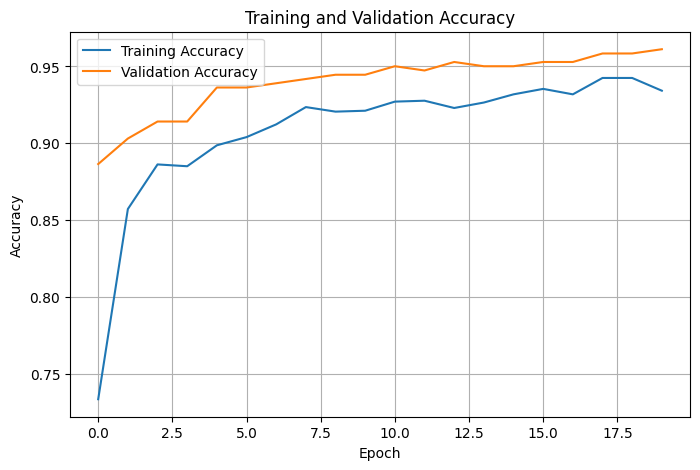

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

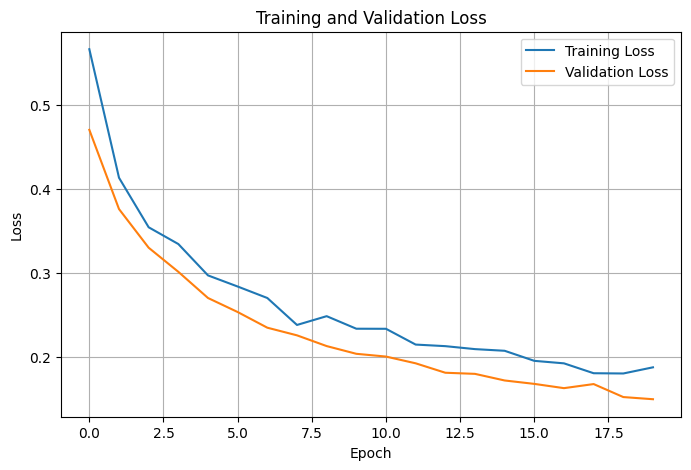

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [ ]:
test_loss, test_accuracy = efficientnet_model.evaluate(
    test_dataset
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 100s 8s/step - accuracy: 0.9588 - loss: 0.1479
Test Loss: 0.14793838560581207
Test Accuracy: 0.958791196346283


In [ ]:
y_true = np.concatenate([
    labels.numpy()
    for images, labels in test_dataset
])

y_pred_prob = efficientnet_model.predict(test_dataset)

y_pred = (
    y_pred_prob >= 0.5
).astype(int).flatten()

12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.class_names,
        digits=4
    )
)

                 precision    recall  f1-score   support

Normal Stitches     0.9577    0.9714    0.9645       210
broken stitches     0.9603    0.9416    0.9508       154

       accuracy                         0.9588       364
      macro avg     0.9590    0.9565    0.9577       364
   weighted avg     0.9588    0.9588    0.9587       364



In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[204   6]
 [  9 145]]


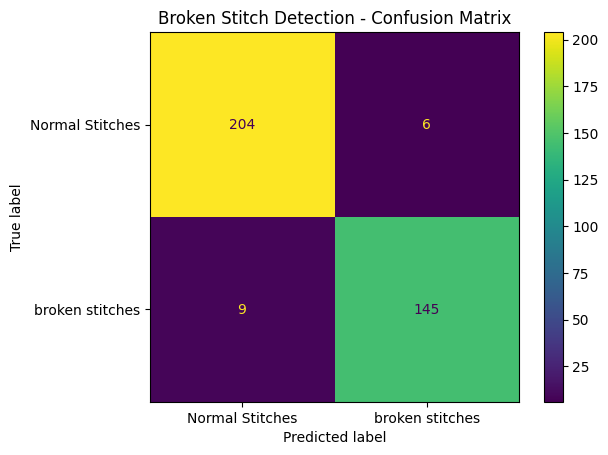

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.class_names
)

disp.plot()

plt.title("Broken Stitch Detection - Confusion Matrix")
plt.show()